# Perceptron

*A Perceptron is one of the simplest and foundational algorithms in machine learning, specifically in binary classification*

## **What Is a Perceptron?**


*A Perceptron is a type of artificial neuron introduced by Frank Rosenblatt in 1958. It forms the basic building block of neural networks.*

It is used to:
- Classify input data into one of two classes (binary classification)
- Make decisions by weighing input signals



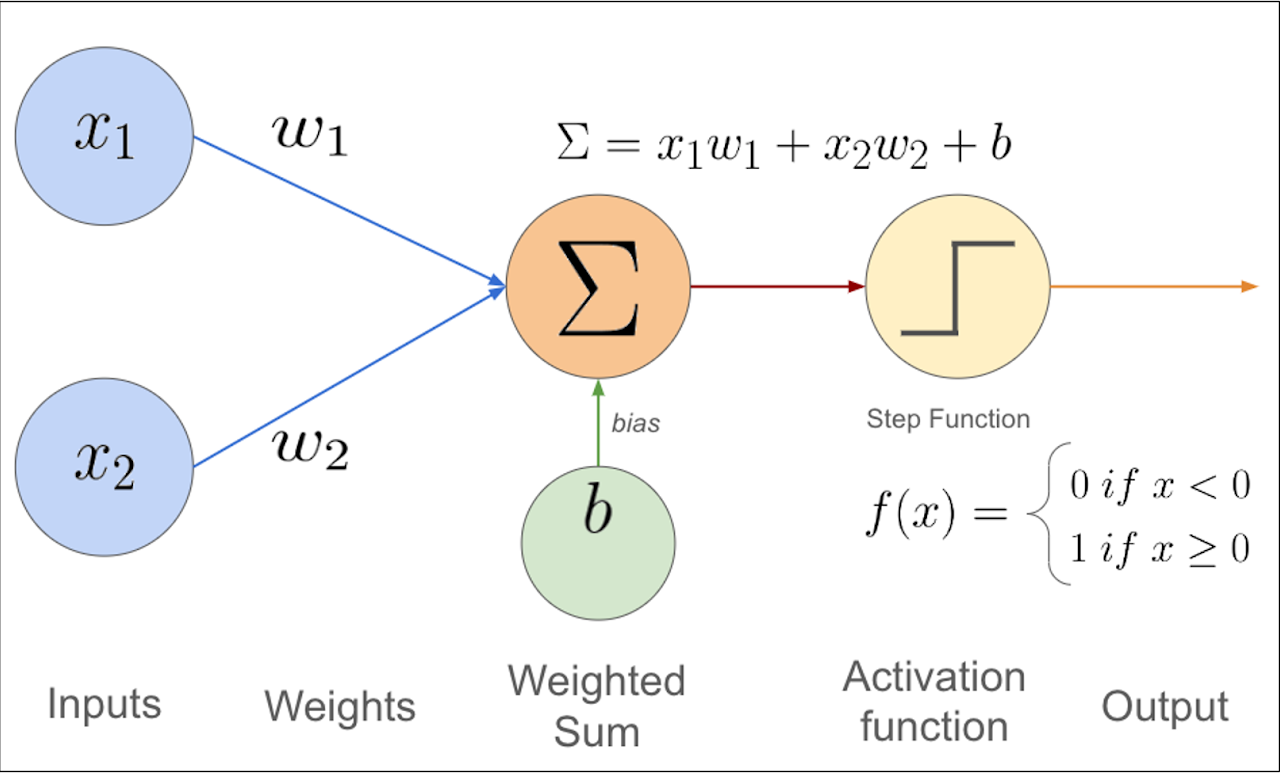

**Where Is It Used?**
- Binary classification tasks (e.g., spam detection, sentiment analysis)
- Foundations for multi-layer neural networks (MLP, Deep Learning)
- Used in scikit-learn as Perceptron classifier

In [58]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 1.4 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.4 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.8 MB/s eta 0:00:00


## Import Libraries (base setup)

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from mlxtend.plotting import plot_decision_regions

## Prepare Data

In [5]:
df=pd.read_csv("placement.csv")
df.columns

Index(['Unnamed: 0', 'cgpa', 'iq', 'placement'], dtype='object')

In [7]:
df.drop(columns='Unnamed: 0' , axis=1,inplace= True)

In [9]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [11]:
df.shape

(100, 3)

<Axes: >

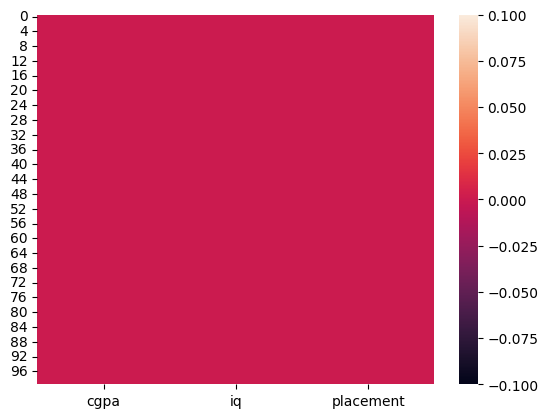

In [13]:
sns.heatmap(df.isna())

In [15]:
df.duplicated().any()

False

<Axes: xlabel='cgpa', ylabel='iq'>

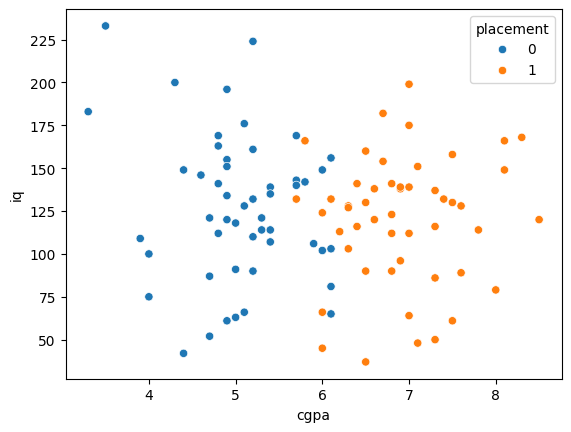

In [17]:
sns.scatterplot(data=df,x=df["cgpa"],y=df['iq'],hue=df["placement"])

In [84]:
X = df[["cgpa", "iq"]]
y = df["placement"]

In [86]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [88]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

## 3 Train-Test Split

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)


## 4. Pipeline with Perceptron + Scaler

In [94]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('perceptron', Perceptron(max_iter=1000, eta0=0.1, random_state=42))
])
pipe.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('perceptron', Perceptron(eta0=0.1, random_state=42))])

In [108]:
pipe.named_steps['perceptron'].coef_


array([[0.41686612, 0.0510767 ]])

In [110]:
pipe.named_steps['perceptron'].intercept_


array([0.])

## 5. Plot Decision Region (No .values)

C:\Users\p4pri\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


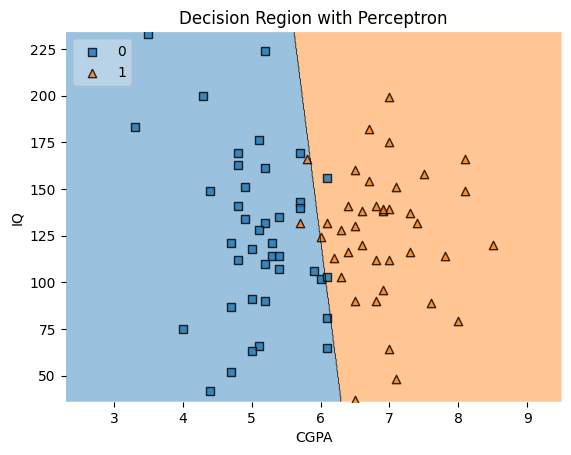

In [101]:
plot_decision_regions(X_train.values, y_train.values, clf=pipe, legend=2)
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("Decision Region with Perceptron")
plt.show()


## 6. Evaluate Performance

In [104]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = pipe.predict(X_test.values)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



C:\Users\p4pri\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## SKLEARN

In [53]:
from sklearn.datasets import load_digits
from sklearn.linear_model import Perceptron
X, y = load_digits(return_X_y=True)
clf = Perceptron(tol=1e-3, random_state=0)
clf.fit(X, y)
clf.score(X, y)

0.9393433500278241